<a href="https://colab.research.google.com/github/NagaSatyaPavani1234/Mobile-Price-Prediction/blob/main/Mobile_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mobile Price Range Prediction Model**

# **Goal:**
**Build and evaluate a supervised learning model.**


# **Introduction**

#Aim:
**To analyze mobile phone specifications and build a machine learning model to predict the price range of a phone based on its features.**

#Dataset:
**Mobile Price Prediction Dataset.**

#Model Used:
**Random Forest Classifier.**

In [ ]:
# Workflow of Machine Learning Model(Bicycle)
'''
0) Import Important dependencies
1) Setting up the data
2) Creating the Model
3) Training the Model
4) Testing the Model
5) Prediction
'''

'\n0) Import Important dependencies\n1) Setting up the data\n2) Creating the Model\n3) Training the Model\n4) Testing the Model\n5) Prediction\n'

In [ ]:
# @title Importing important dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix

In [ ]:
# @title Converting csv file into Dataframe
df=pd.read_csv("Mobile_Price_Range_Prediction.csv")

# **Understanding the Dataframe**

In [ ]:
# @title Checking the values of DataFrame
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [ ]:
# @title Shape of the Dataframe
df.shape

(2000, 21)

In [ ]:
# @title Using shape to find the number of rows
print("Total number of rows = ",df.shape[0])

Total number of rows =  2000


In [ ]:
# @title Using shape to find the number of Columns

print("Total number of columns = ",df.shape[1])

Total number of columns =  21


In [ ]:
# @title Dimensions of the Dataframe
np.ndim(df)

2

In [ ]:
# @title Printing all the column names
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [ ]:
# @title Describing the statistical informarion of numerical columns
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


# **Data Preprocessing**

In [ ]:
# @title Counting the null values
df.isnull().sum().reset_index()

,index,0
0,battery_power,0
1,blue,0
2,clock_speed,0
3,dual_sim,0
4,fc,0
5,four_g,0
6,int_memory,0
7,m_dep,0
8,mobile_wt,0
9,n_cores,0


since there is no null values in the dataframe no need for handling the null values

In [ ]:
# @title Checking for any duplicates in the Dataframe
df.duplicated().sum()

np.int64(0)

since there is no duplicate values are present in the dataframe. So removal of duplicates is not required.

In [ ]:
# @title checking the datatypes of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

 since there is no categorical datatype present in the dataframe Categorical encoding is not required

# **Statistical Analysis**

In [ ]:
# @title Statistical summary of the battery_power
df["battery_power"].describe()

,battery_power
count,2000.000000
mean,1238.518500
std,439.418206
min,501.000000
25%,851.750000
50%,1226.000000
75%,1615.250000
max,1998.000000


In [ ]:
# @title Statistical summary of the price range
df['price_range'].describe()

,price_range
count,2000.000000
mean,1.500000
std,1.118314
min,0.000000
25%,0.750000
50%,1.500000
75%,2.250000
max,3.000000


In [ ]:
# @title finding the unique_values of price range and counting them
df['price_range'].value_counts().reset_index()

,price_range,count
0,1,500
1,2,500
2,3,500
3,0,500


In [ ]:
# @title Median of the price_range feature
print("Median of the price range column is",df['price_range'].median())

Median of the price range column is 1.5


In [ ]:
# @title Mode of the price_range feature
print("Mode of the price range column is",df['price_range'].mode())


Mode of the price range column is 0    0
1    1
2    2
3    3
Name: price_range, dtype: int64


# **Feature Engeneering**

In [ ]:
# @title Adding screen area
df["screen_area"] = df["sc_h"] * df["sc_w"]

In [ ]:
# @title Adding memory power
df["memory_power"] = df["ram"] + df["int_memory"]

In [ ]:
# @title Adding performance score
df["performance_score"] = df["ram"] * df["n_cores"]

# **Data Analysis**

In [ ]:
# @title How many unique RAM values exist in the dataset?
df['ram'].nunique()

1562

In [ ]:
# @title How does RAM vary across different price ranges?
df.groupby(by='price_range')['ram'].mean().reset_index()

,price_range,ram
0,0,785.314
1,1,1679.490
2,2,2582.816
3,3,3449.232


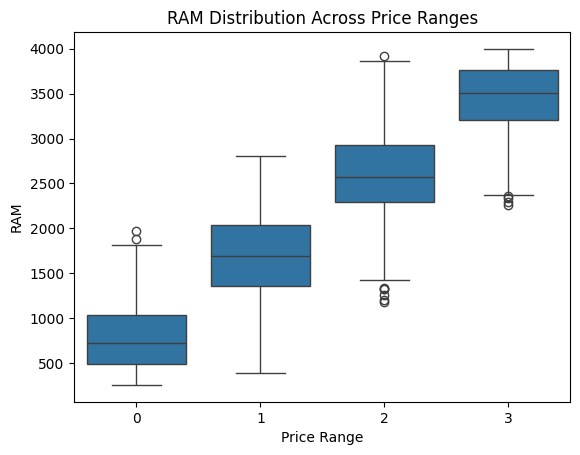

In [ ]:
# @title Plot
sns.boxplot(x='price_range', y='ram', data=df)
plt.title("RAM Distribution Across Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("RAM")
plt.show()

# Observation or Insight

- In the boxplot it is showing that the mobiles with High RAM has High Price.
- So RAM one of the most influencing factor of the price.

In [ ]:
# @title Which factor has the strongest correlation with price range?
correlation=df.corr()
print(correlation['price_range'].sort_values(ascending=False))

price_range          1.000000
memory_power         0.917158
ram                  0.917046
performance_score    0.614958
battery_power        0.200723
px_width             0.165818
px_height            0.148858
int_memory           0.044435
screen_area          0.041248
sc_w                 0.038711
pc                   0.033599
three_g              0.023611
sc_h                 0.022986
fc                   0.021998
talk_time            0.021859
blue                 0.020573
wifi                 0.018785
dual_sim             0.017444
four_g               0.014772
n_cores              0.004399
m_dep                0.000853
clock_speed         -0.006606
mobile_wt           -0.030302
touch_screen        -0.030411
Name: price_range, dtype: float64


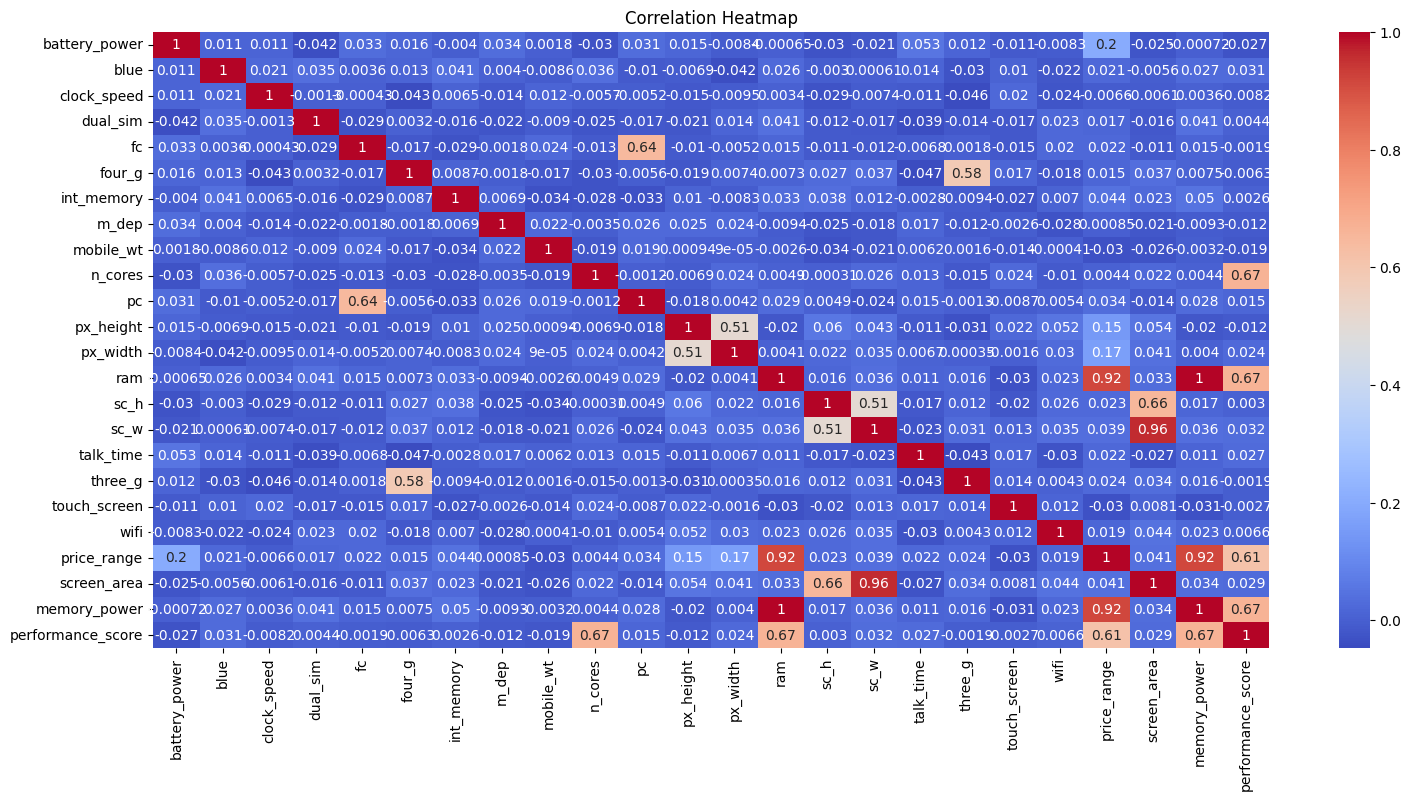

In [ ]:
# @title Correlation  Heatmap Plot
plt.figure(figsize=(18,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Observation
- The heatplot shows that RAM has strong relation with price range and followed by pxe; resolution and battery

In [ ]:
# @title Does every Price range contains dual sim phones?
#Crosstab  basically counts combinations of categories.
pd.crosstab(df['dual_sim'], df['price_range'])

price_range,0,1,2,3
dual_sim,,,,
0,250,245,251,235
1,250,255,249,265


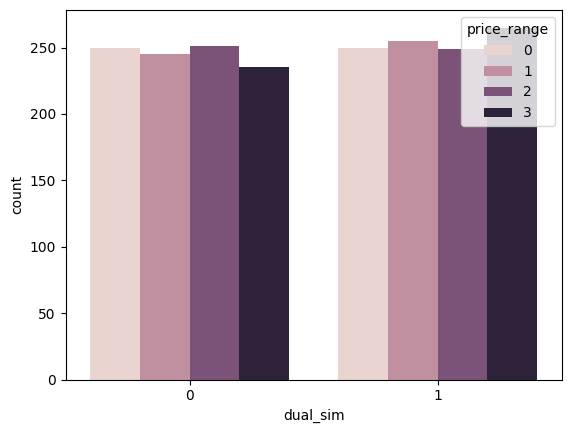

In [ ]:
# @title  Plot
sns.countplot(x='dual_sim', hue='price_range', data=df)
plt.show()

# Observation
The count plot indicates that dual SIM phones are present across all price ranges. The distribution is relatively balanced, suggesting that dual SIM capability is not a major factor affecting mobile price classification.

In [ ]:
# @title What proportion of phones support wifi
cond1=(df['wifi']==1)
print("The number of mobiles support wifi is = ",df[cond1].shape[0])
print("The percentage of mobiles support wifi is = ",(df[cond1].shape[0]/df["wifi"].shape[0])*100,'%')


The number of mobiles support wifi is =  1014
The percentage of mobiles support wifi is =  50.7 %


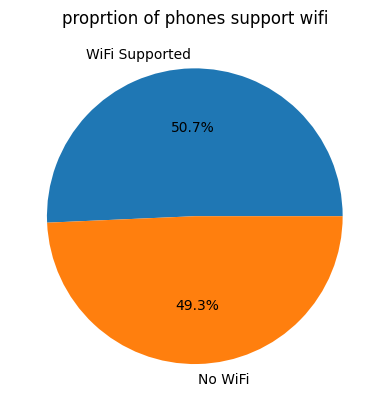

In [ ]:
# @title Plot

counts=df["wifi"].value_counts()
plt.pie(counts, labels=['WiFi Supported', 'No WiFi'], autopct='%1.1f%%')
plt.title("proprtion of phones support wifi")
plt.show()

# Observations
The pie chart shows that approximately half of the mobile phones support WiFi, while the remaining half do not support WiFi.

In [ ]:
# @title How does battery power vary across different mobile price ranges?
df.groupby('price_range')['battery_power'].mean().reset_index()


,price_range,battery_power
0,0,1116.902
1,1,1228.868
2,2,1228.320
3,3,1379.984


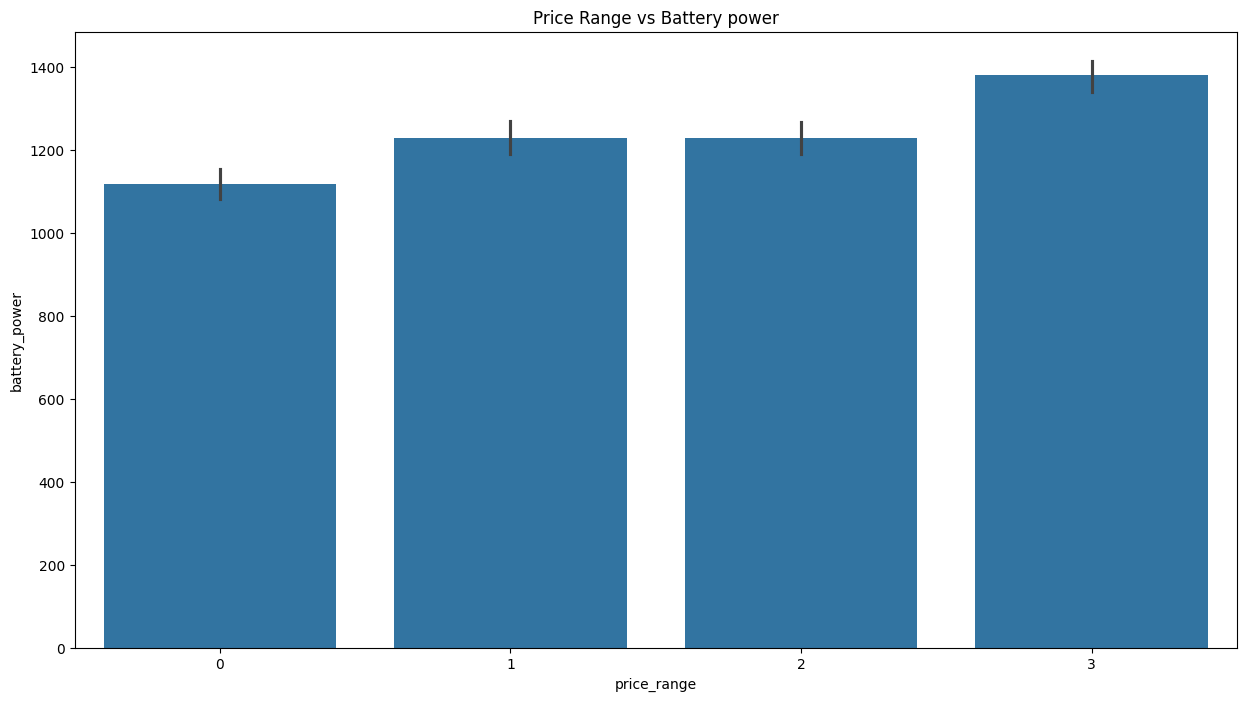

In [ ]:
# @title Plot
plt.figure(figsize=(15,8))
sns.barplot(x='price_range',y='battery_power',data=df)
plt.title('Price Range vs Battery power')
plt.show()

# Observation
- The bar plot shows the average battery power for each price range category. It can be observed that phones in higher price ranges generally tend to have higher battery power compared to lower price categories.

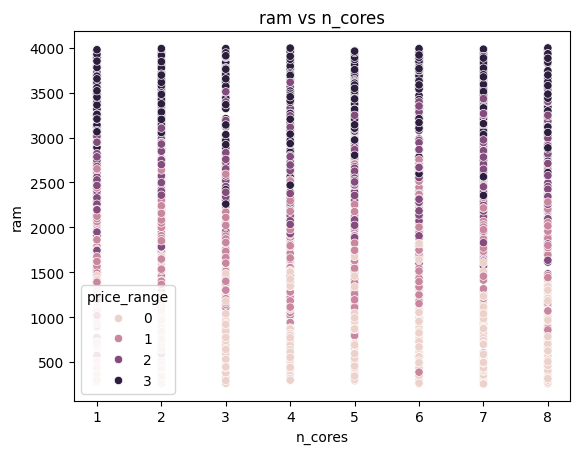

In [ ]:
# @title Relation between ram and ncores

sns.scatterplot(x="n_cores", y="ram", hue="price_range", data=df)
plt.title("ram vs n_cores")
plt.show()

# Observation
The scatter plot shows that mobiles with more processor cores tend to have higher RAM values, although RAM is distributed across all core categories.

# **Feature Selection**

In [ ]:
# Here Price range is the target column
# Store the input in x
# Store target column in y
x = df.drop(['price_range'], axis=1)
y = df["price_range"]



In [ ]:
x

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,screen_area,memory_power,performance_score
0,842,0,2.2,0,1,0,7,0.6,188,2,...,2549,9,7,19,0,0,1,63,2556,5098
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,2631,17,3,7,1,1,0,51,2684,7893
2,563,1,0.5,1,2,1,41,0.9,145,5,...,2603,11,2,9,1,1,0,22,2644,13015
3,615,1,2.5,0,0,0,10,0.8,131,6,...,2769,16,8,11,1,0,0,128,2779,16614
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1411,8,2,15,1,1,0,16,1455,2822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,668,13,4,19,1,1,0,52,670,4008
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,2032,11,10,16,1,1,1,110,2071,8128
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,3057,9,1,5,1,1,0,9,3093,24456
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,869,18,10,19,1,1,1,180,915,4345


In [ ]:
y

,price_range
0,1
1,2
2,2
3,2
4,1
...,...
1995,0
1996,2
1997,3
1998,0


In [ ]:
# @title Train Test Split
#Splitting the data into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [ ]:
print(x.shape)

(2000, 23)


In [ ]:
print(x_train.shape)

(1600, 23)


In [ ]:
print(x_test.shape)

(400, 23)


In [ ]:
print(y.shape)

(2000,)


In [ ]:
print(y_train.shape)

(1600,)


In [ ]:
print(y_test.shape)

(400,)


# **Model Training**

In [ ]:
# Training the model with training data
model=RandomForestClassifier()
model.fit(x_train,y_train)



RandomForestClassifier()

# Model Evaluation

In [ ]:
#It is also called as Testing the Model


In [ ]:
# @title Accuracy score of training data
training_data_prediction=model.predict(x_train)
training_data_accuracy=accuracy_score(y_train,training_data_prediction)
print("Accuracy score of training data is",training_data_accuracy)

Accuracy score of training data is 1.0


In [ ]:
# @title Acuuracy score of testing data
testing_data_prediction=model.predict(x_test)
testing_data_accuracy=accuracy_score(y_test,testing_data_prediction)
print("Accuracy score of testing data is",testing_data_accuracy)

Accuracy score of testing data is 0.885


In [ ]:
# prediction for testing data
testing_data_prediction = model.predict(x_test)

# testing accuracy
test_accuracy_score = accuracy_score(y_test, testing_data_prediction)
print("accuracy score of testing data is", test_accuracy_score)

accuracy score of testing data is 0.885


In [ ]:
# @title Calculating the Precision , Recall , F1 score
precision = precision_score(y_test, testing_data_prediction, average='weighted')
recall = recall_score(y_test, testing_data_prediction, average='weighted')
f1 = f1_score(y_test, testing_data_prediction, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8864090569164847
Recall: 0.885
F1 Score: 0.885536398317517


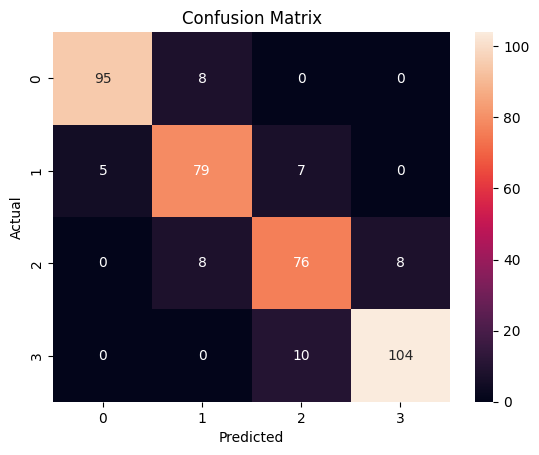

In [ ]:
# @title Confusion Matrix
import seaborn as sns
cm = confusion_matrix(y_test, testing_data_prediction)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Observation of Model Evalution**
- From the model evaluation results, we can see that the Random Forest model gives a good accuracy in predicting the mobile price range.
- The precision, recall, and F1-score values are also quite high, which means the model is able to classify most of the phones into the correct price category.
- Overall, the model performs well and makes reliable predictions based on the phone specifications.

# **Visualisation**

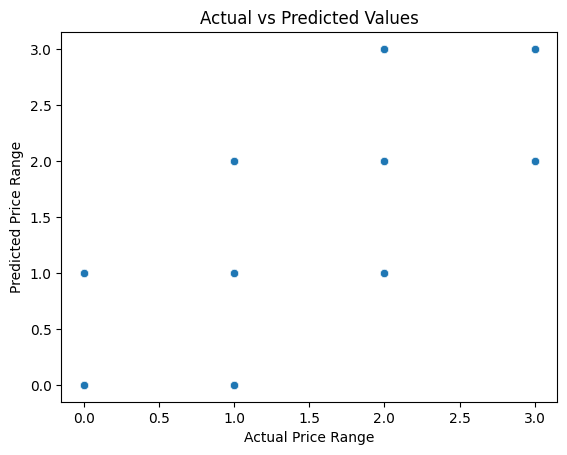

In [ ]:
# @title Plotting Actual vs Predictied data
sns.scatterplot(x=y_test, y=testing_data_prediction)
plt.xlabel("Actual Price Range")
plt.ylabel("Predicted Price Range")
plt.title("Actual vs Predicted Values")
plt.show()


# Observation
- From the scatter plot, we can see that most of the predicted values are very close to the actual price ranges.
- This shows that the model is doing a good job in predicting the correct price category, with only a few predictions slightly off.

# Building the Predictive system


In [ ]:
# example input data (must follow the same order as dataset features)
input_data = (1520,1,2.2,0,5,1,33,0.5,177,8,18,151,1005,3826,14,9,13,1,1,1
)

# convert to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the data for prediction
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)




In [ ]:
x.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'screen_area', 'memory_power',
       'performance_score'],
      dtype='object')

In [ ]:
# @title Calculating newly created columns
screenarea=input_data_reshaped[0][14]*input_data_reshaped[0][15]
memory_power=input_data_reshaped[0][6]+input_data_reshaped[0][13]
performance_score=input_data_reshaped[0][13]*input_data_reshaped[0][9]

In [ ]:
# @title Adding newly created column values to the input array
added=np.asarray([screenarea,memory_power,performance_score]).reshape(1,-1)
final_input=np.append(input_data_reshaped,added,axis=1)


In [ ]:
# @title Prediction
prediction=model.predict(final_input)
print("The model predicted price range is",prediction)


The model predicted price range is [3]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#**Observation(ML model)**
From the model evaluation, it can be seen that the Random Forest model predicts the mobile price range quite well. The accuracy, precision, recall, and F1-score values show that the model is able to correctly classify most of the phones into the right price category based on their specifications.


# ***Conclusion***
In this project, I worked on building a machine learning model to predict the price range of mobile phones using various specifications. I applied feature engineering to create new features like screen_area, memory_power, and performance_score, which improved the model’s understanding of the data. The model achieved good accuracy, and this project helped me understand how important feature engineering and proper data analysis are in developing effective machine learning models.